In [6]:
import sounddevice as sd
from scipy.io.wavfile import write

sample_rate = 16000
duration = 10
filename = "output.wav"

print("Recording...")
recording = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
sd.wait()
write(filename, sample_rate, recording)
print("Saved to output.wav")

Recording...
Saved to output.wav


In [ ]:
from collections import defaultdict

# each key maps to a list by default
database = defaultdict(list)

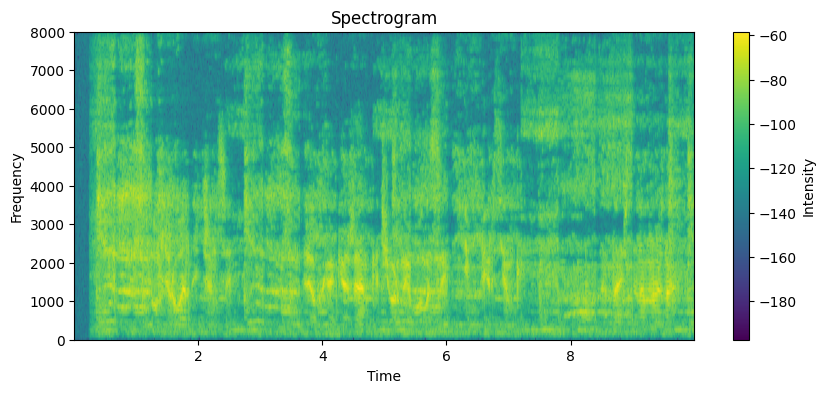

In [7]:
import matplotlib.pyplot as plt
from scipy.io import wavfile

sample_rate, signal = wavfile.read("output.wav")

if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

plt.figure(figsize=(10, 4))
plt.specgram(signal, Fs=sample_rate)
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.colorbar(label="Intensity")
plt.show()

In [8]:
from scipy.io import wavfile
from scipy.signal import stft
import numpy as np

sample_rate, signal = wavfile.read("output.wav")

if len(signal.shape) == 2:
    signal = signal.mean(axis=1)

f, t, Zxx = stft(signal, fs=sample_rate, nperseg=1024)

spec = np.abs(Zxx)
log_spec = np.log1p(spec)

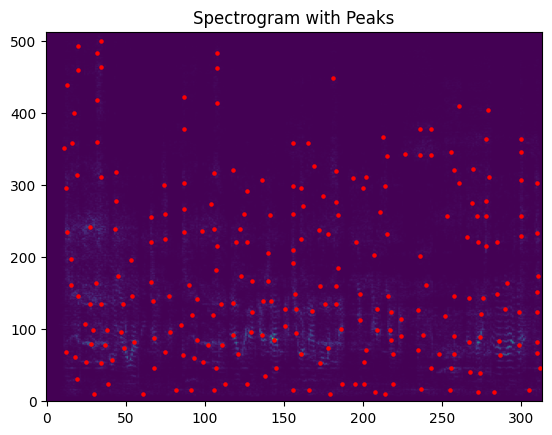

In [9]:
from scipy.ndimage import maximum_filter

neighborhood_size = (30, 10)
local_max = maximum_filter(log_spec, size=neighborhood_size) == log_spec

threshold = np.mean(log_spec) + 0.5 * np.std(log_spec)
detected_peaks = local_max & (log_spec > threshold)

freq_idx, time_idx = np.where(detected_peaks)

# FIX 3: sort by amplitude FIRST, then cap — not the other way around
max_peaks = 500
peaks = sorted(zip(freq_idx, time_idx, log_spec[freq_idx, time_idx]), key=lambda x: -x[2])
peaks = peaks[:max_peaks]

# FIX 2: derive plot indices from the final peaks list, not stale freq_idx/time_idx
plot_freq = [p[0] for p in peaks]
plot_time = [p[1] for p in peaks]

import matplotlib.pyplot as plt
plt.imshow(log_spec, aspect='auto', origin='lower')
plt.scatter(plot_time, plot_freq, color='red', s=5)
plt.title("Spectrogram with Peaks")
plt.show()

In [10]:
FAN_OUT = 5
MAX_TIME_DELTA = 50

# FIX 4: separate time-sorted list for hashing so delta_t is always positive
peaks_by_time = sorted(peaks, key=lambda x: x[1])

hashes = []

for i in range(len(peaks_by_time)):
    # FIX 1: unpack all 3 elements
    f1, t1, _ = peaks_by_time[i]

    pairs_found = 0
    j = i + 1

    # FIX 4: walk forward in time until we find FAN_OUT valid pairs or exceed MAX_TIME_DELTA
    while j < len(peaks_by_time) and pairs_found < FAN_OUT:
        f2, t2, _ = peaks_by_time[j]
        delta_t = t2 - t1  # guaranteed positive now

        if delta_t > MAX_TIME_DELTA:
            break  # no point looking further, list is time-sorted

        hash_value = (f1, f2, delta_t)
        hashes.append((hash_value, t1))
        pairs_found += 1
        j += 1

print(f"Total hashes generated: {len(hashes)}")



Total hashes generated: 1200
